# Automobile Dataset Analysis

---
## 1. Library Imports

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sp
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

#Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


---
## 2. Data Loading

In [ ]:
df = pd.read_csv("automobiles.csv")
print(f"Dimensions: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Variables: {list(df.columns)}")

Dimensions: 392 rows × 9 columns
Variables: ['miles_per_gallon', 'cylinders', 'displacement', 'horsepower', 'weight_lbs', 'acceleration', 'model_year', 'origin_country', 'car_name']


In [29]:
df.head(10) # showing 10 first cars

,miles_per_gallon,cylinders,displacement,horsepower,weight_lbs,acceleration,model_year,origin_country,car_name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
5,15.0,8,429.0,198,4341,10.0,70,1,ford galaxie 500
6,14.0,8,454.0,220,4354,9.0,70,1,chevrolet impala
7,14.0,8,440.0,215,4312,8.5,70,1,plymouth fury iii
8,14.0,8,455.0,225,4425,10.0,70,1,pontiac catalina
9,15.0,8,390.0,190,3850,8.5,70,1,amc ambassador dpl


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   miles_per_gallon  392 non-null    float64
 1   cylinders         392 non-null    int64  
 2   displacement      392 non-null    float64
 3   horsepower        392 non-null    int64  
 4   weight_lbs        392 non-null    int64  
 5   acceleration      392 non-null    float64
 6   model_year        392 non-null    int64  
 7   origin_country    392 non-null    int64  
 8   car_name          392 non-null    object 
dtypes: float64(3), int64(5), object(1)
memory usage: 27.7+ KB


---
## 3. Data Cleaning


In [31]:
missing = df.isna().sum() # showing all missing data
print("Missing values:", missing[missing > 0] if missing.sum() > 0 else "None")
df_clean = df.dropna() # remove all missing data (no data are missing)
print(f"Cleaned dataset: {len(df_clean)} rows")

Missing values: None
Cleaned dataset: 392 rows


---
## 4. Statistical Description

### 4.1 General Statistics

In [32]:
df_clean.describe()

,miles_per_gallon,cylinders,displacement,horsepower,weight_lbs,acceleration,model_year,origin_country
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592,1.576531
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737,0.805518
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000,1.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


### 4.2 Detailed Quantitative Variables

In [33]:
quantitative_vars = ['miles_per_gallon', 'cylinders', 'displacement', 
              'horsepower', 'weight_lbs', 'acceleration', 'model_year']

stats_list = []
for var in quantitative_vars:
    stats_list.append({
        'Variable': var,
        'Mean': f"{df_clean[var].mean():.2f}",
        'Median': f"{df_clean[var].median():.2f}",
        'Std': f"{df_clean[var].std():.2f}",
        'Min': f"{df_clean[var].min():.2f}",
        'Max': f"{df_clean[var].max():.2f}"
    })
pd.DataFrame(stats_list)

,Variable,Mean,Median,Std,Min,Max
0,miles_per_gallon,23.45,22.75,7.81,9.00,46.60
1,cylinders,5.47,4.00,1.71,3.00,8.00
2,displacement,194.41,151.00,104.64,68.00,455.00
3,horsepower,104.47,93.50,38.49,46.00,230.00
4,weight_lbs,2977.58,2803.50,849.40,1613.00,5140.00
5,acceleration,15.54,15.50,2.76,8.00,24.80
6,model_year,75.98,76.00,3.68,70.00,82.00


### 4.3 Vehicle Origin

In [34]:
origin_map = {1: 'USA', 2: 'Europe', 3: 'Japan'}
df_clean['origin_name'] = df_clean['origin_country'].map(origin_map)
print("Distribution:")
print(df_clean['origin_name'].value_counts())
print("\nProportions:")
print((df_clean['origin_name'].value_counts(normalize=True)*100).round(2))

Distribution:
origin_name
USA       245
Japan      79
Europe     68
Name: count, dtype: int64

Proportions:
origin_name
USA       62.50
Japan     20.15
Europe    17.35
Name: proportion, dtype: float64


---
## 5. Exploratory Visualizations

### 5.1 Distributions

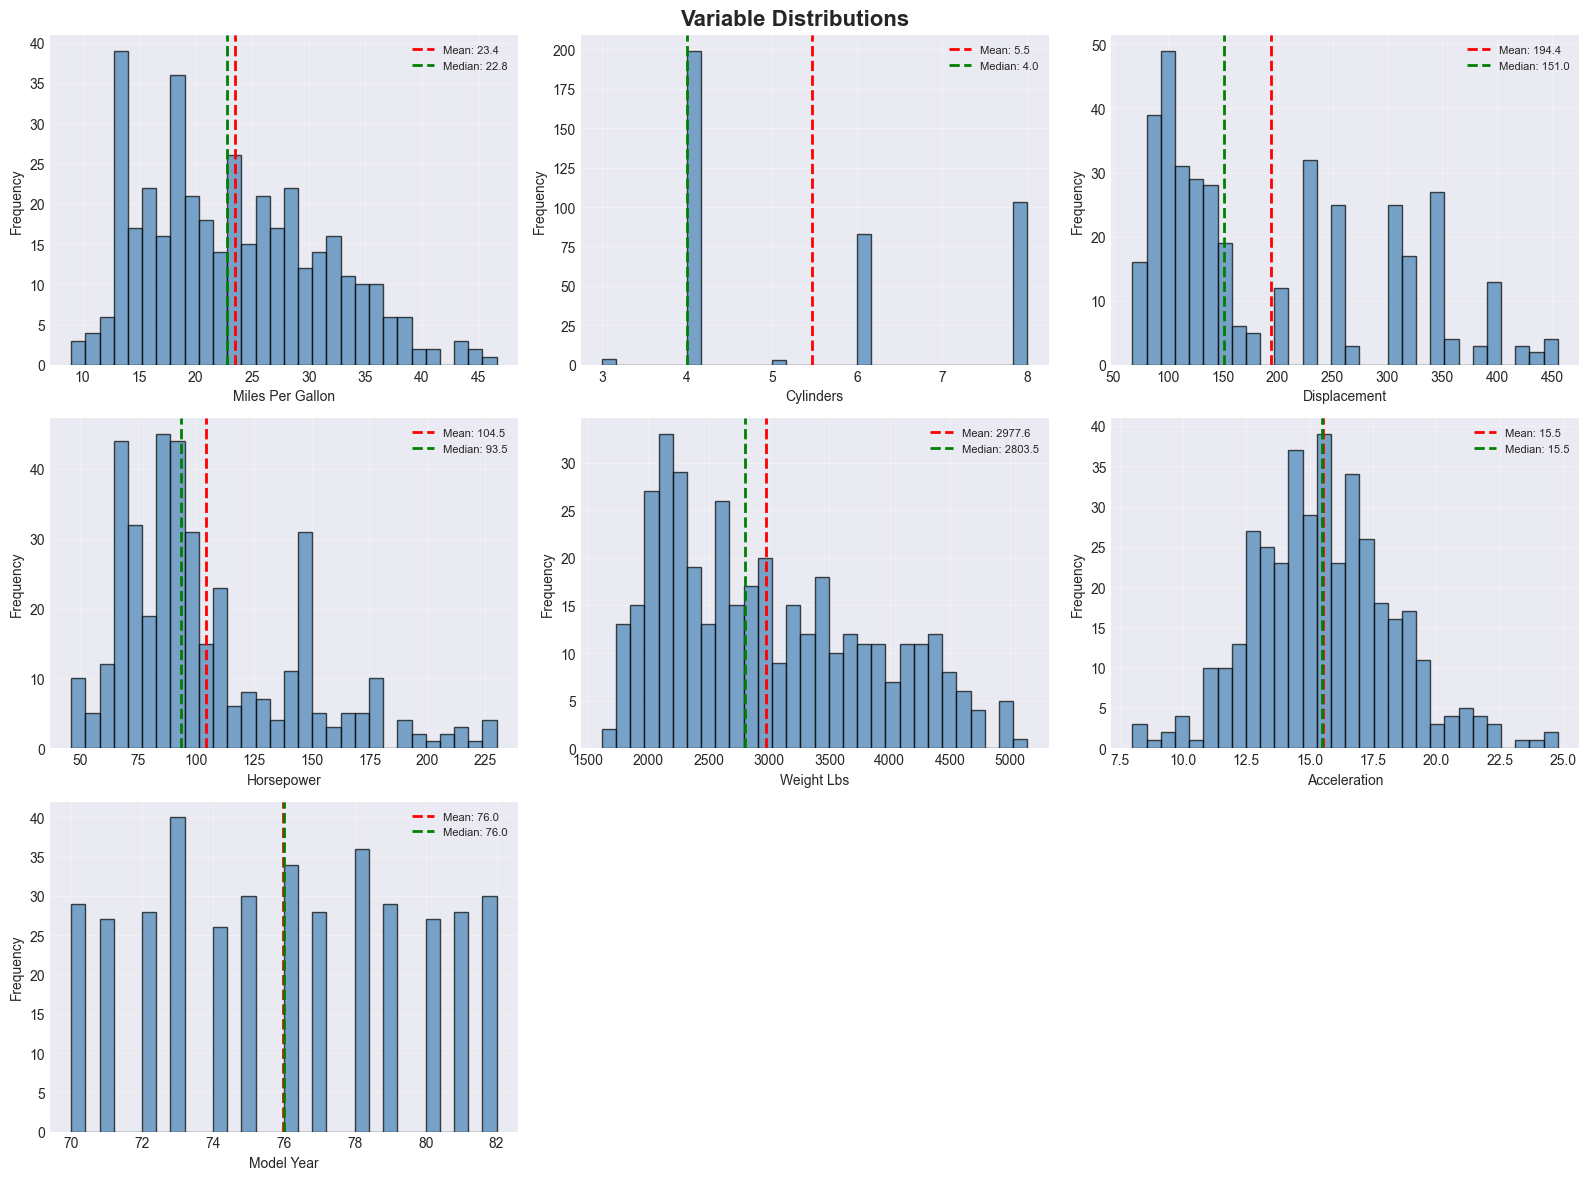

In [35]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Variable Distributions', fontsize=16, fontweight='bold')

for idx, var in enumerate(quantitative_vars):
    row, col = idx // 3, idx % 3
    ax = axes[row, col]
    ax.hist(df_clean[var], bins=30, alpha=0.7, edgecolor='black', color='steelblue')
    mean_val = df_clean[var].mean()
    median_val = df_clean[var].median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')
    ax.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.1f}')
    ax.set_xlabel(var.replace('_', ' ').title())
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

for idx in range(len(quantitative_vars), 9):
    fig.delaxes(axes[idx // 3, idx % 3])
plt.tight_layout()
plt.show()

### 5.2 Comparison by Origin

In [36]:
# Average statistics by origin
vars_plot = ['miles_per_gallon', 'horsepower', 'weight_lbs', 
             'acceleration', 'displacement', 'cylinders']

origin_stats = df_clean.groupby('origin_name')[vars_plot].mean().round(2)
print("Average characteristics by origin:")
print(origin_stats)

Average characteristics by origin:
             miles_per_gallon  horsepower  weight_lbs  acceleration  \
origin_name                                                           
Europe                  27.60       80.56     2433.47         16.79   
Japan                   30.45       79.84     2221.23         16.17   
USA                     20.03      119.05     3372.49         14.99   

             displacement  cylinders  
origin_name                           
Europe             109.63       4.16  
Japan              102.71       4.10  
USA                247.51       6.28  


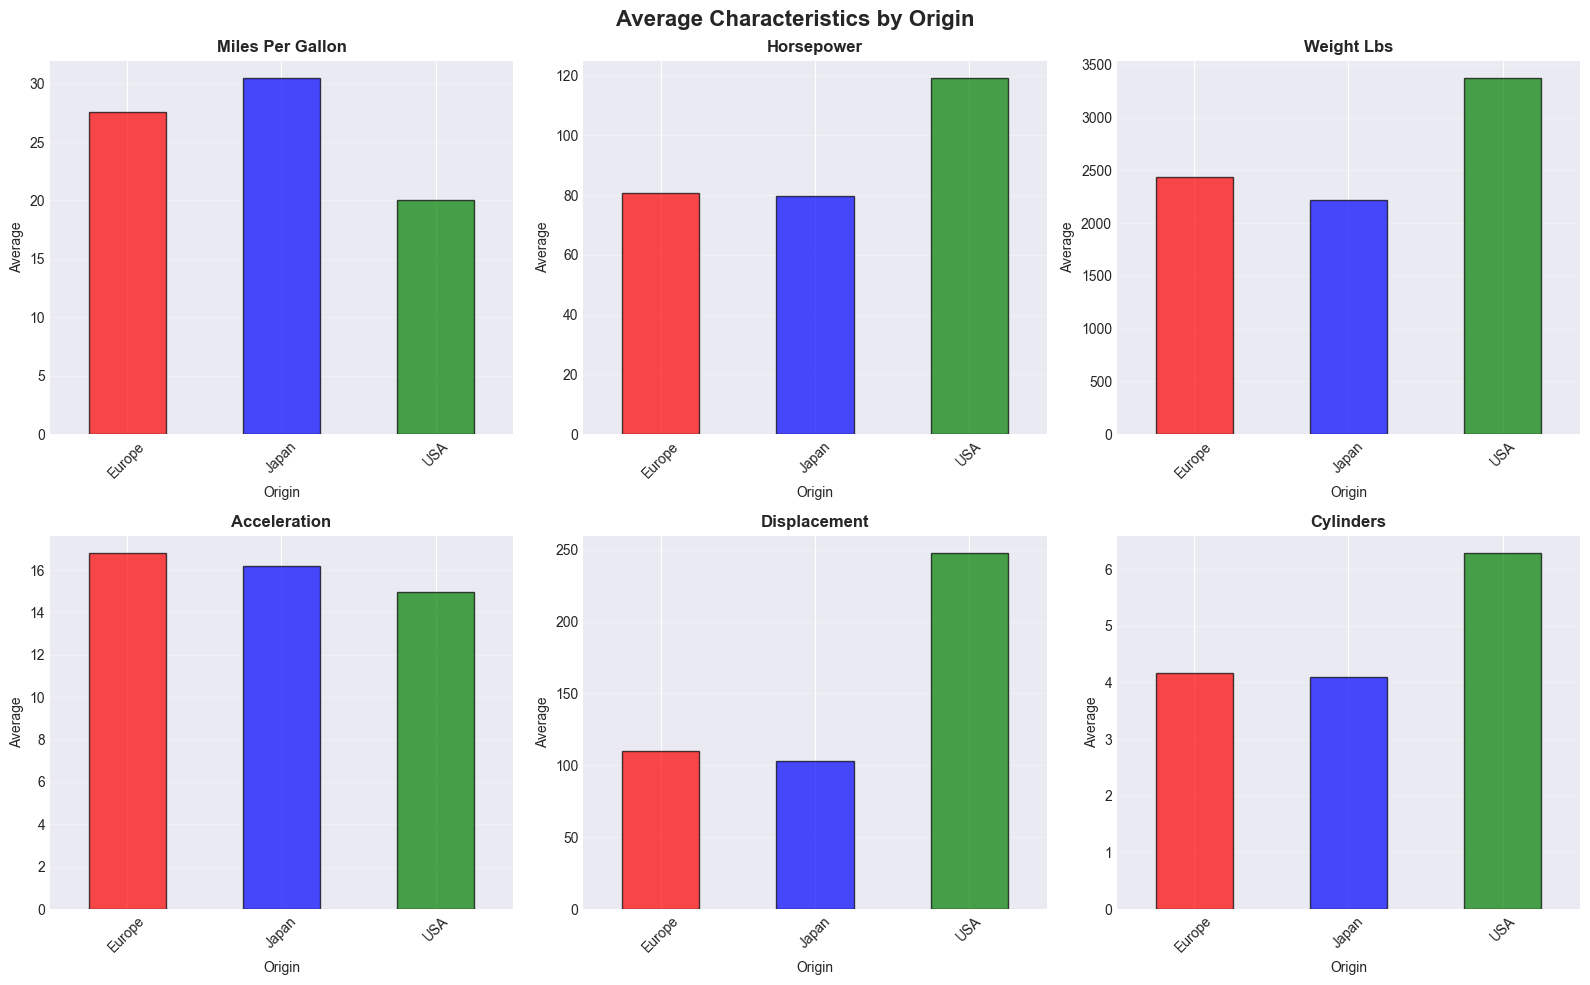

In [37]:
# Bar charts for key variables
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Average Characteristics by Origin', fontsize=16, fontweight='bold')

for idx, var in enumerate(vars_plot):
    row, col = idx // 3, idx % 3
    ax = axes[row, col]
    
    # Calculate means by origin
    means = df_clean.groupby('origin_name')[var].mean()
    colors = ['red', 'blue', 'green']
    
    means.plot(kind='bar', ax=ax, color=colors, alpha=0.7, edgecolor='black')
    ax.set_title(var.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel('Origin')
    ax.set_ylabel('Average')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

### 5.3 Correlations

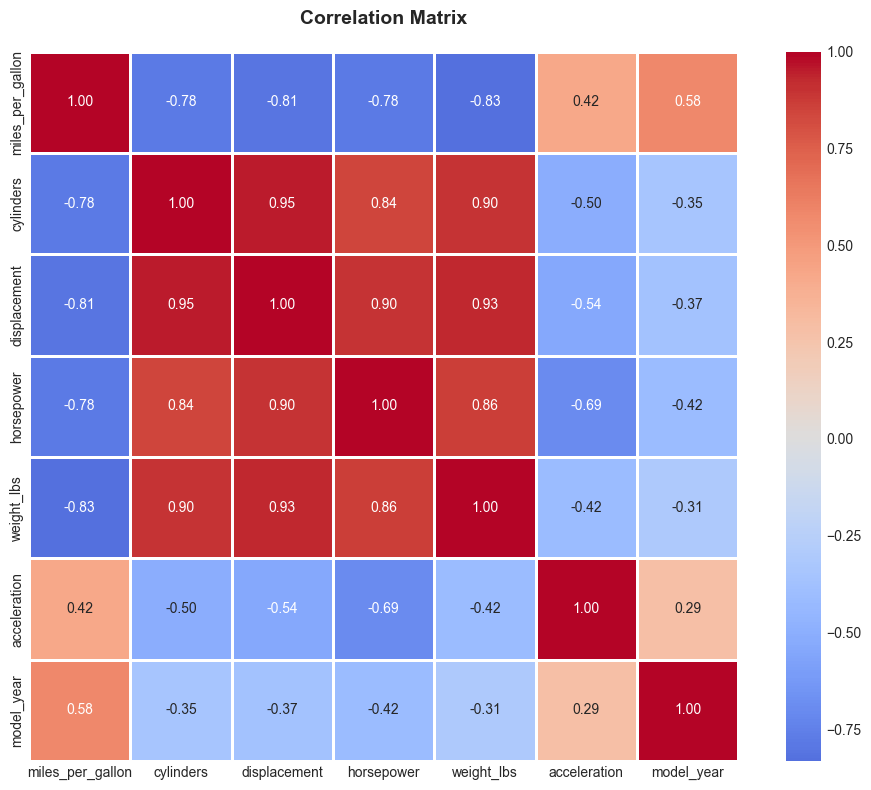

In [38]:
plt.figure(figsize=(10, 8))
correlation_matrix = df_clean[quantitative_vars].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [39]:
# Correlations with MPG
mpg_corr = correlation_matrix['miles_per_gallon'].drop('miles_per_gallon').sort_values()
print("Correlations with MPG:")
for var, corr in mpg_corr.items():
    print(f"{var:20s}: {corr:+.3f}")

Correlations with MPG:
weight_lbs          : -0.832
displacement        : -0.805
horsepower          : -0.778
cylinders           : -0.778
acceleration        : +0.423
model_year          : +0.581


### 5.4 Pairplot

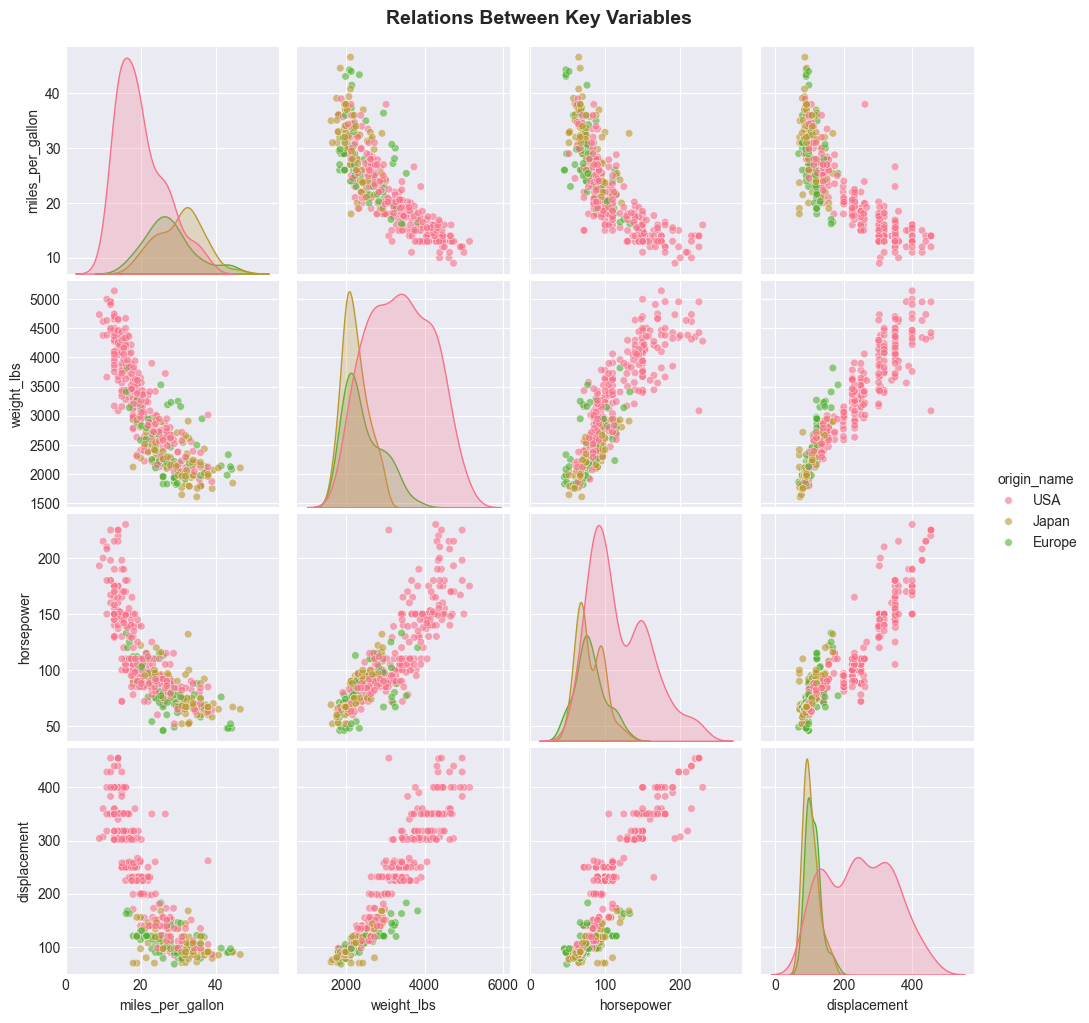

In [40]:
key_vars = ['miles_per_gallon', 'weight_lbs', 'horsepower', 'displacement']
sns.pairplot(df_clean[key_vars + ['origin_name']], hue='origin_name', 
             diag_kind='kde', plot_kws={'alpha': 0.6, 's': 30}, height=2.5)
plt.suptitle('Relations Between Key Variables', y=1.02, fontsize=14, fontweight='bold')
plt.show()

---
## 6. CAFE Analysis (24 mpg)

### 6.1 Compliance

In [41]:
df_clean['meets_cafe'] = df_clean['miles_per_gallon'] >= 24
n_meets = df_clean['meets_cafe'].sum()
n_total = len(df_clean)
pct = (n_meets/n_total)*100
print(f"Cars >=24 mpg: {n_meets}/{n_total} ({pct:.1f}%)")

Cars >=24 mpg: 181/392 (46.2%)


### 6.2 Characteristics

In [42]:
comparison = df_clean.groupby('meets_cafe')[quantitative_vars].mean().T
comparison.columns = ['< 24 mpg', '>= 24 mpg']
comparison['Diff %'] = ((comparison['>= 24 mpg']-comparison['< 24 mpg'])/comparison['< 24 mpg']*100).round(1)
comparison.round(2)

,< 24 mpg,>= 24 mpg,Diff %
miles_per_gallon,17.37,30.53,75.7
cylinders,6.62,4.13,-37.6
displacement,264.79,112.37,-57.6
horsepower,127.44,77.69,-39.0
weight_lbs,3558.46,2300.43,-35.4
acceleration,14.73,16.49,11.9
model_year,74.52,77.69,4.3


### 6.3 CAFE Visualizations

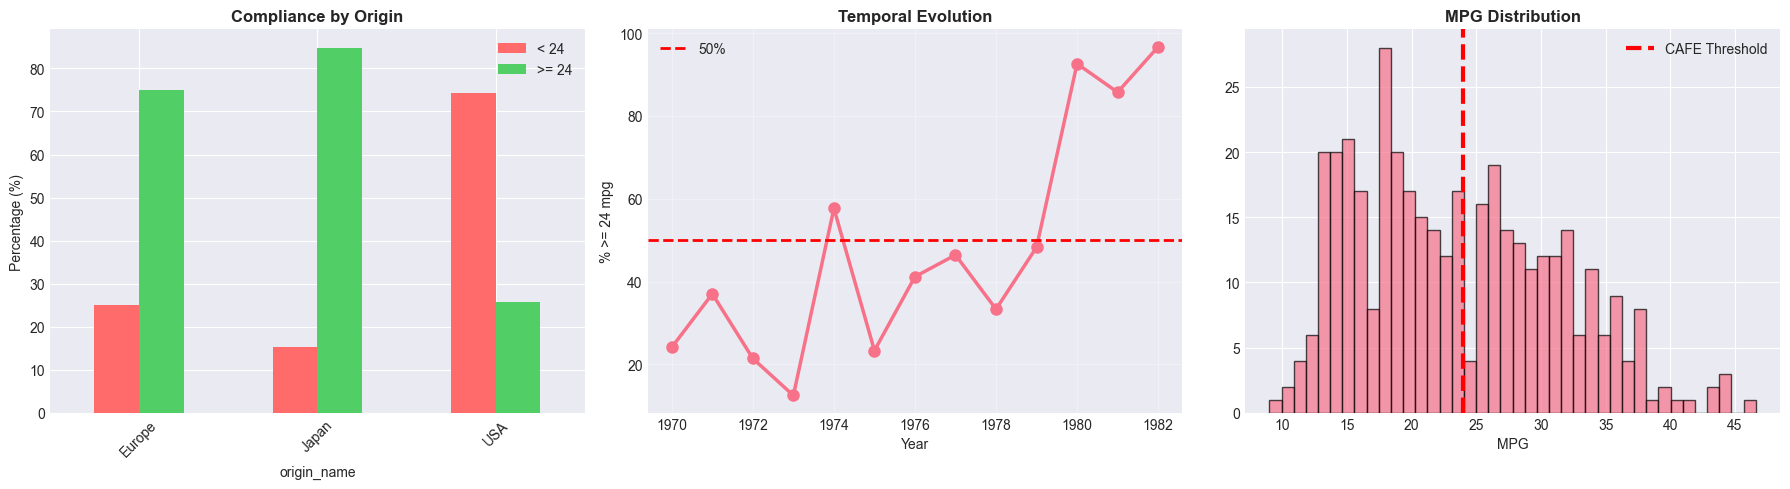

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# By origin
cafe_origin = pd.crosstab(df_clean['origin_name'], df_clean['meets_cafe'], normalize='index')*100
cafe_origin.plot(kind='bar', ax=axes[0], color=['#ff6b6b', '#51cf66'])
axes[0].set_title('Compliance by Origin', fontweight='bold')
axes[0].set_ylabel('Percentage (%)')
axes[0].legend(['< 24', '>= 24'])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

# Evolution
cafe_year = df_clean.groupby('model_year')['meets_cafe'].mean()*100
axes[1].plot(cafe_year.index+1900, cafe_year.values, marker='o', linewidth=2.5, markersize=8)
axes[1].axhline(50, color='red', linestyle='--', linewidth=2, label='50%')
axes[1].set_title('Temporal Evolution', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('% >= 24 mpg')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Distribution with threshold
axes[2].hist(df_clean['miles_per_gallon'], bins=40, alpha=0.7, edgecolor='black')
axes[2].axvline(24, color='red', linestyle='--', linewidth=3, label='CAFE Threshold')
axes[2].set_title('MPG Distribution', fontweight='bold')
axes[2].set_xlabel('MPG')
axes[2].legend()

plt.tight_layout()
plt.show()

---
## 7. Principal Component Analysis

### 7.1 Standardization

In [44]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[quantitative_vars])
print(f"Standardized: {X_scaled.shape}")
print(f"Mean: {X_scaled.mean():.10f}, Std: {X_scaled.std():.10f}")

Standardized: (392, 7)
Mean: -0.0000000000, Std: 1.0000000000


### 7.2 Explained Variance

In [45]:
pca_full = PCA()
X_pca = pca_full.fit_transform(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print("Explained variance:")
for i, (var, cum) in enumerate(zip(explained_var, cumulative_var), 1):
    print(f"PC{i}: {var*100:5.2f}% (cum: {cum*100:5.2f}%)")

n_90 = np.argmax(cumulative_var >= 0.90) + 1
print(f"\n {n_90} components for 90% variance")

Explained variance:
PC1: 71.58% (cum: 71.58%)
PC2: 12.37% (cum: 83.95%)
PC3: 10.41% (cum: 94.35%)
PC4:  2.63% (cum: 96.98%)
PC5:  1.74% (cum: 98.72%)
PC6:  0.78% (cum: 99.50%)
PC7:  0.50% (cum: 100.00%)

 3 components for 90% variance


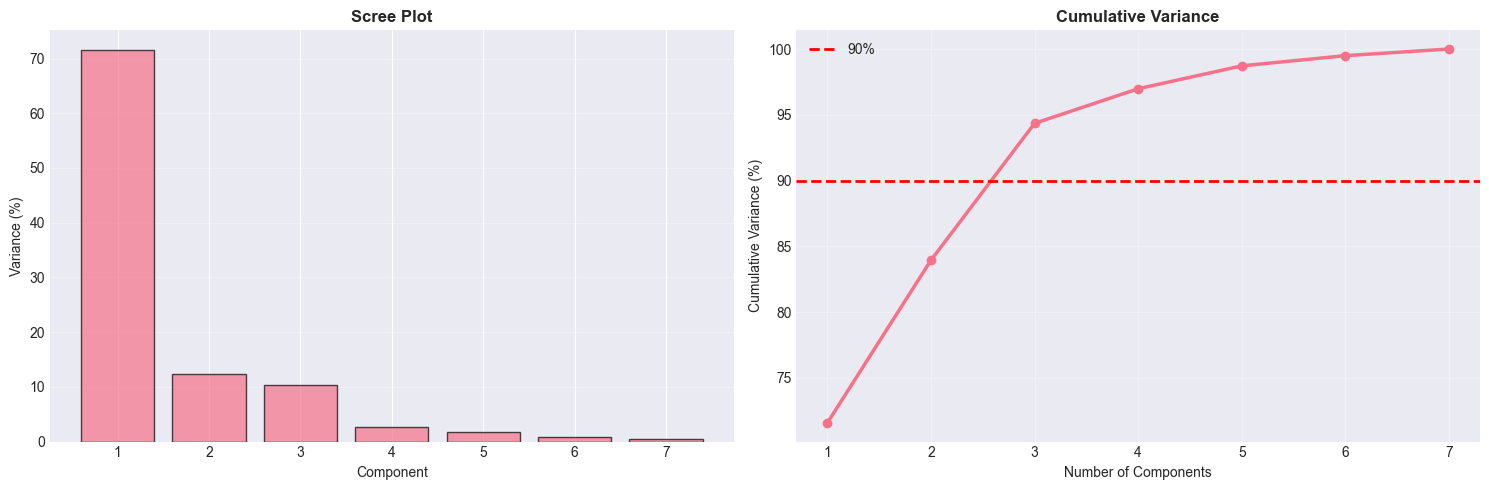

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scree plot
axes[0].bar(range(1, len(explained_var)+1), explained_var*100, alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Variance (%)')
axes[0].set_title('Scree Plot', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Cumulative
axes[1].plot(range(1, len(cumulative_var)+1), cumulative_var*100, marker='o', linewidth=2.5)
axes[1].axhline(90, color='red', linestyle='--', linewidth=2, label='90%')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_title('Cumulative Variance', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 7.3 2D Projection

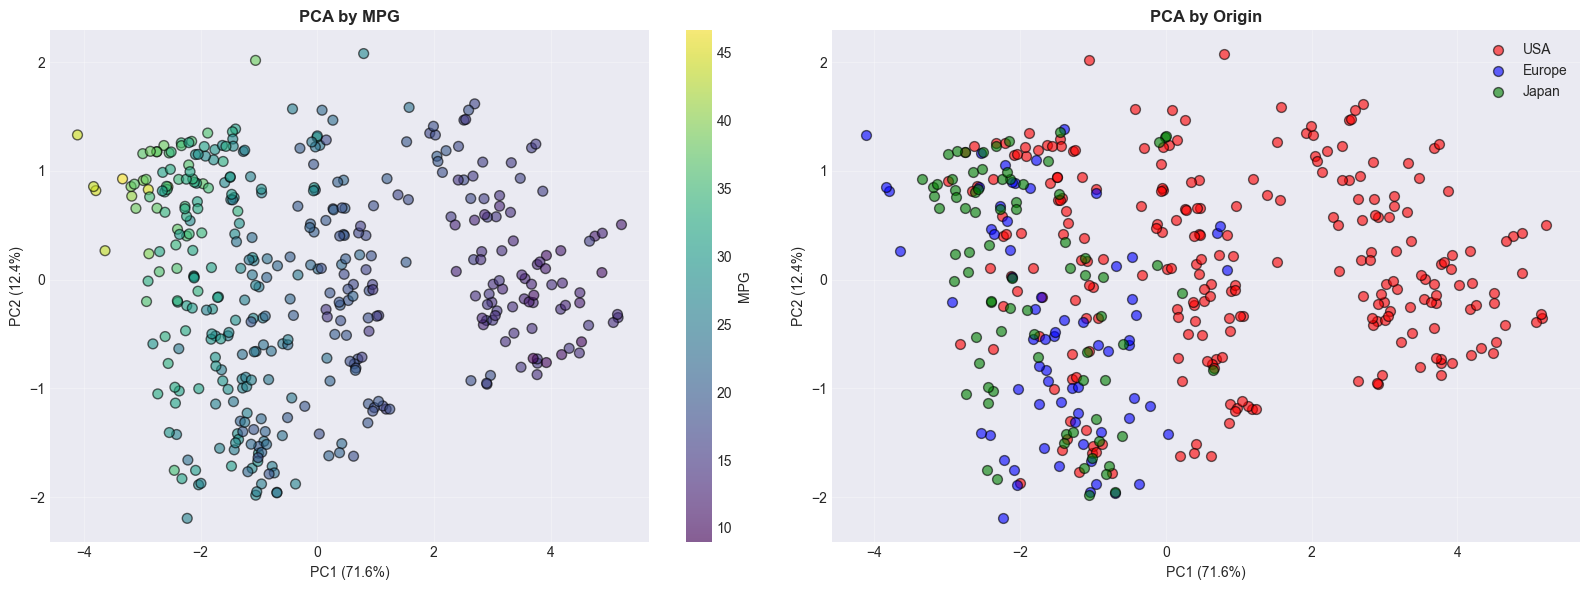

In [47]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# By MPG
scatter1 = axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=df_clean['miles_per_gallon'], 
                           cmap='viridis', alpha=0.6, edgecolor='black', s=50)
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('PCA by MPG', fontweight='bold')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='MPG')

# By origin
colors = {'USA': 'red', 'Europe': 'blue', 'Japan': 'green'}
for origin, color in colors.items():
    mask = df_clean['origin_name'] == origin
    axes[1].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], 
                   label=origin, alpha=0.6, edgecolor='black', s=50, c=color)
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('PCA by Origin', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 7.4 Contributions

Contributions:
                    PC1    PC2
miles_per_gallon -0.398  0.207
cylinders         0.416  0.199
displacement      0.429  0.180
horsepower        0.423  0.085
weight_lbs        0.414  0.225
acceleration     -0.285 -0.007
model_year       -0.230  0.910


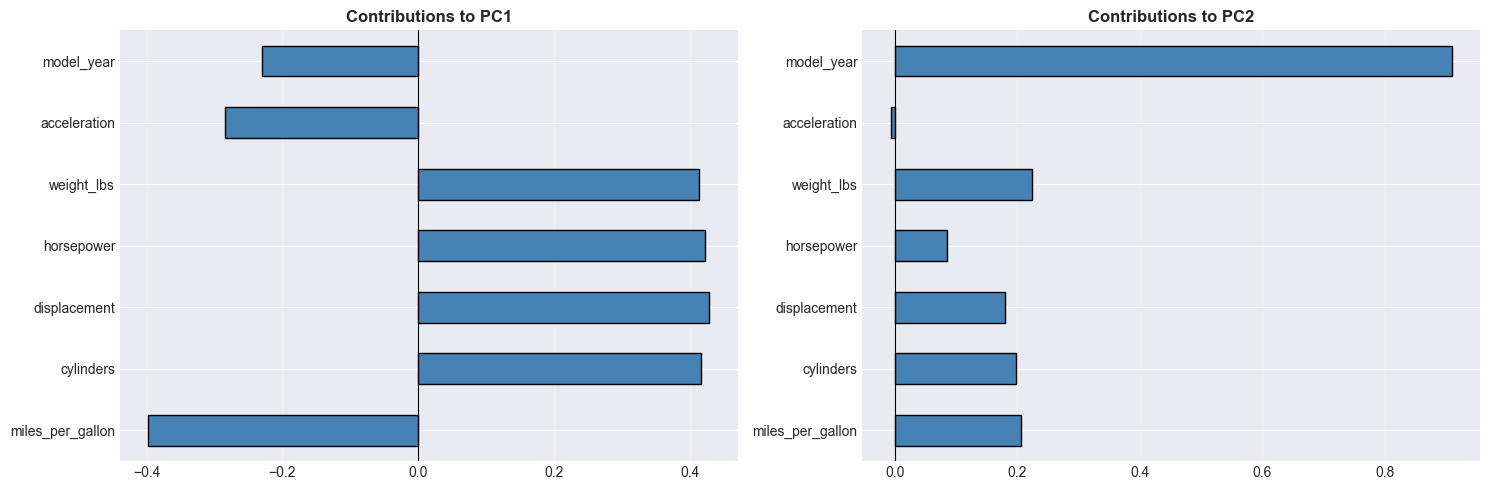

In [48]:
components_df = pd.DataFrame(pca_2d.components_.T, columns=['PC1', 'PC2'], index=quantitative_vars)
print("Contributions:")
print(components_df.round(3))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for i, pc in enumerate(['PC1', 'PC2']):
    components_df[pc].plot(kind='barh', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'Contributions to {pc}', fontweight='bold')
    axes[i].axvline(0, color='black', linewidth=0.8)
    axes[i].grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

---
## 8. Regression Analysis

### 8.1 Preparation

In [49]:
from sklearn.preprocessing import PolynomialFeatures

X = df_clean[['weight_lbs']].values
y = df_clean['miles_per_gallon'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 313, Test: 79


### 8.2 Polynomial Regression

In [54]:
#Test polynomial degrees
degrees = [1, 2, 3]
results = []

for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    y_pred_test = model.predict(X_test_poly)
    r2 = r2_score(y_test, y_pred_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    
    results.append({'Degree': degree, 'R^2 Test': r2, 'RMSE': rmse})
    print(f"Degree {degree}: R^2 = {r2:.4f}, RMSE = {rmse:.2f}")

results_df = pd.DataFrame(results)

Degree 1: R^2 = 0.6533, RMSE = 4.21
Degree 2: R^2 = 0.6730, RMSE = 4.09
Degree 3: R^2 = 0.6730, RMSE = 4.09


### 8.3 Visualization

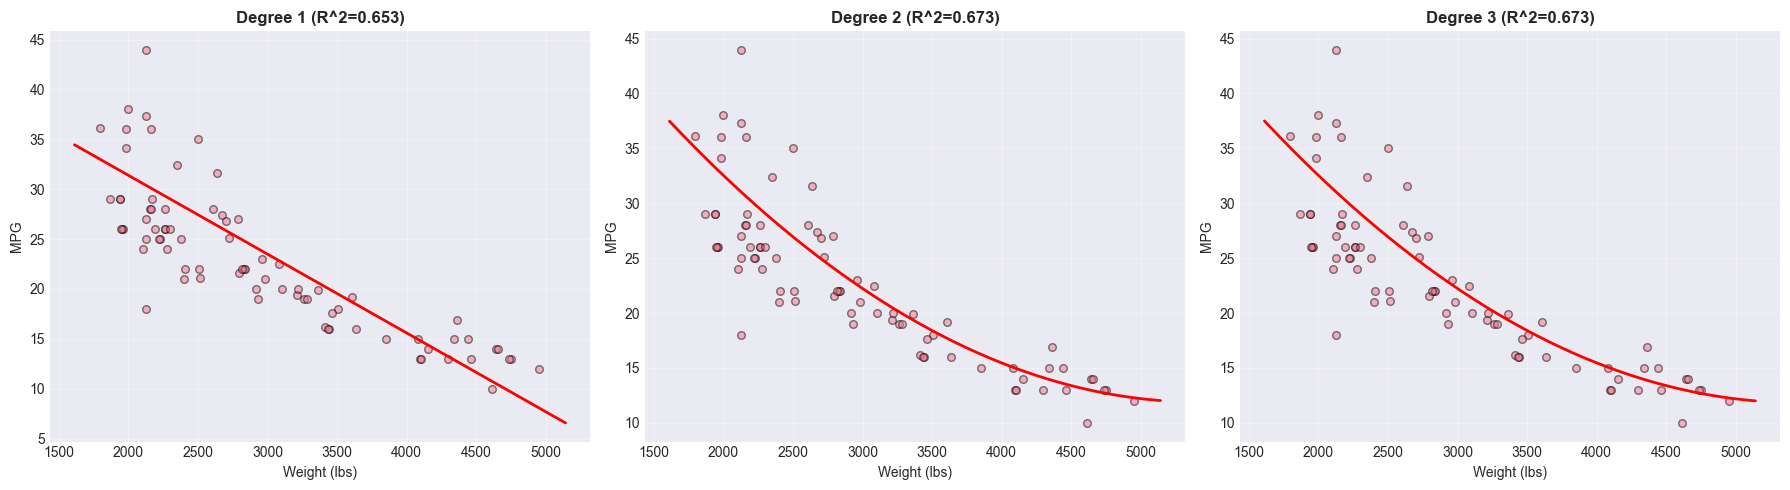

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, degree in enumerate(degrees):
    ax = axes[idx]
    
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    y_pred_test = model.predict(X_test_poly)
    
    # Smooth curve
    X_range = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
    X_range_poly = poly.transform(X_range)
    y_range_pred = model.predict(X_range_poly)
    
    ax.scatter(X_test, y_test, alpha=0.5, s=30, edgecolor='black')
    ax.plot(X_range, y_range_pred, 'r-', linewidth=2)
    ax.set_xlabel('Weight (lbs)')
    ax.set_ylabel('MPG')
    ax.set_title(f'Degree {degree} (R^2={r2_score(y_test, y_pred_test):.3f})', fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 8.4 Comparison

In [52]:
X_multi = df_clean[['cylinders', 'displacement', 'horsepower', 'weight_lbs', 'acceleration']].values
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y, test_size=0.2, random_state=42)

model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)
y_pred_multi = model_multi.predict(X_test_m)
r2_multi = r2_score(y_test_m, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test_m, y_pred_multi))

print(f"Linear (weight):      R^2 = 0.6533, RMSE = 4.21")
print(f"Polynomial deg 2:     R^2 = {results_df.loc[1, 'R^2 Test']:.4f}, RMSE = {results_df.loc[1, 'RMSE']:.2f}")
print(f"Polynomial deg 3:     R^2 = {results_df.loc[2, 'R^2 Test']:.4f}, RMSE = {results_df.loc[2, 'RMSE']:.2f}")
print(f"Multiple (5 vars):    R^2 = {r2_multi:.4f}, RMSE = {rmse_multi:.2f}")


Linear (weight):      R^2 = 0.6533, RMSE = 4.21
Polynomial deg 2:     R^2 = 0.6730, RMSE = 4.09
Polynomial deg 3:     R^2 = 0.6730, RMSE = 4.09
Multiple (5 vars):    R^2 = 0.6485, RMSE = 4.24
